## CELL 1 — Install/import/configuration

In [1]:
# Kaggle usually already contains these packages.
# Run this only if an import below fails.
# !pip install -q catboost pyarrow

from pathlib import Path
import re
import gc
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

# =========================================================
# CONFIGURATION
# =========================================================

INPUT_ROOT = Path("/kaggle/input")

WORK_ROOT = Path("/kaggle/working/member3_demand_forecasting")

OUTPUT_DIR = WORK_ROOT / "outputs"
MODEL_DIR = WORK_ROOT / "models"
SPLIT_DIR = WORK_ROOT / "data_splits"
FIGURE_DIR = WORK_ROOT / "figures"
PROCESSED_DIR = WORK_ROOT / "processed"

for d in [
    WORK_ROOT,
    OUTPUT_DIR,
    MODEL_DIR,
    SPLIT_DIR,
    FIGURE_DIR,
    PROCESSED_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

# Memory-friendly CSV reading
CHUNK_SIZE = 500_000

# Competition requirement: top taxi zones
TOP_N_ZONES = 10

# Chronological validation/test windows
VALIDATION_DAYS = 14
TEST_DAYS = 14

# Competition forecast horizon
FORECAST_HORIZON = 72

RANDOM_SEED = 42

print("Pipeline configuration ready.")
print("Output folder:", WORK_ROOT)

Pipeline configuration ready.
Output folder: /kaggle/working/member3_demand_forecasting


## CELL 2 — Automatically find all 12 taxi files

In [2]:
# =========================================================
# FIND TAXI FILES
# =========================================================

taxi_files = sorted(
    INPUT_ROOT.rglob("taxi_*_cleaned.csv")
)

print(f"Found {len(taxi_files)} cleaned taxi files:\n")

for f in taxi_files:
    print(f)

if len(taxi_files) != 12:
    raise ValueError(
        f"Expected 12 monthly cleaned taxi files but found {len(taxi_files)}. "
        "Check that all files were added to the Kaggle notebook."
    )


# =========================================================
# VALIDATE MONTH SEQUENCE
# =========================================================

pattern = re.compile(r"taxi_(\d{4}-\d{2})_cleaned\.csv$")

file_months = []

for f in taxi_files:
    match = pattern.search(f.name)

    if match:
        file_months.append(
            pd.Period(match.group(1), freq="M")
        )
    else:
        raise ValueError(
            f"Unexpected filename format: {f.name}"
        )

file_months = sorted(file_months)

expected_months = list(
    pd.period_range(
        start=file_months[0],
        end=file_months[-1],
        freq="M"
    )
)

missing_months = sorted(
    set(expected_months) - set(file_months)
)

print("\nMonth range:")
print(file_months[0], "→", file_months[-1])

if missing_months:
    raise ValueError(
        f"Missing monthly files: {missing_months}"
    )

print("All months are continuous.")


# =========================================================
# FIND ZONE FILE
# =========================================================

zone_candidates = list(
    INPUT_ROOT.rglob(
        "Urban_Flow_Analytics_Zone_Dataset.csv"
    )
)

if len(zone_candidates) == 0:
    raise FileNotFoundError(
        "Urban_Flow_Analytics_Zone_Dataset.csv not found."
    )

ZONE_PATH = zone_candidates[0]

print("\nZone dataset:")
print(ZONE_PATH)

Found 12 cleaned taxi files:

/kaggle/input/datasets/dulharakaushalya/datathon-2026/taxi_2025-04_cleaned.csv
/kaggle/input/datasets/dulharakaushalya/datathon-2026/taxi_2025-05_cleaned.csv
/kaggle/input/datasets/dulharakaushalya/datathon-2026/taxi_2025-06_cleaned.csv
/kaggle/input/datasets/dulharakaushalya/datathon-2026/taxi_2025-07_cleaned.csv
/kaggle/input/datasets/dulharakaushalya/datathon-2026/taxi_2025-08_cleaned.csv
/kaggle/input/datasets/dulharakaushalya/datathon-2026/taxi_2025-09_cleaned.csv
/kaggle/input/datasets/dulharakaushalya/datathon-2026/taxi_2025-10_cleaned.csv
/kaggle/input/datasets/dulharakaushalya/datathon-2026/taxi_2025-11_cleaned.csv
/kaggle/input/datasets/dulharakaushalya/datathon-2026/taxi_2025-12_cleaned.csv
/kaggle/input/datasets/dulharakaushalya/datathon-2026/taxi_2026-01_cleaned.csv
/kaggle/input/datasets/dulharakaushalya/datathon-2026/taxi_2026-02_cleaned.csv
/kaggle/input/datasets/dulharakaushalya/datathon-2026/taxi_2026-03_cleaned.csv

Month range:
2025-04 

## CELL 3 — Aggregate all 12 months without loading them together

In [3]:
# =========================================================
# MONTHLY CHUNKED AGGREGATION
# =========================================================

REQUIRED_COLUMNS = [
    "pickup_timestamp",
    "origin_loc_id"
]


def aggregate_one_file(file_path, chunk_size=500_000):
    """
    Read a large taxi CSV in chunks and immediately convert
    individual trips into hourly pickup counts per zone.
    """

    aggregated_chunks = []

    total_rows = 0
    valid_rows = 0

    print("\n" + "=" * 70)
    print("Processing:", file_path.name)
    print("=" * 70)

    reader = pd.read_csv(
        file_path,
        usecols=REQUIRED_COLUMNS,
        chunksize=chunk_size,
        low_memory=False
    )

    for chunk_number, chunk in enumerate(reader, start=1):

        total_rows += len(chunk)

        # Convert timestamp safely
        chunk["pickup_timestamp"] = pd.to_datetime(
            chunk["pickup_timestamp"],
            errors="coerce"
        )

        # Convert location safely
        chunk["origin_loc_id"] = pd.to_numeric(
            chunk["origin_loc_id"],
            errors="coerce"
        )

        # Demand forecasting only requires valid pickup
        # timestamp and pickup location
        valid = (
            chunk["pickup_timestamp"].notna()
            & chunk["origin_loc_id"].notna()
        )

        chunk = chunk.loc[
            valid,
            REQUIRED_COLUMNS
        ].copy()

        valid_rows += len(chunk)

        chunk["origin_loc_id"] = (
            chunk["origin_loc_id"]
            .astype("int32")
        )

        # Convert trips to hourly timestamps
        chunk["pickup_hour_timestamp"] = (
            chunk["pickup_timestamp"]
            .dt.floor("h")
        )

        # Count pickups per zone/hour inside this chunk
        agg = (
            chunk
            .groupby(
                [
                    "pickup_hour_timestamp",
                    "origin_loc_id"
                ],
                as_index=False
            )
            .size()
            .rename(
                columns={"size": "trip_demand"}
            )
        )

        aggregated_chunks.append(agg)

        print(
            f"Chunk {chunk_number:,} "
            f"| rows processed: {total_rows:,}"
        )

        del chunk
        gc.collect()

    # Combine chunk-level counts for the month
    monthly = pd.concat(
        aggregated_chunks,
        ignore_index=True
    )

    monthly = (
        monthly
        .groupby(
            [
                "pickup_hour_timestamp",
                "origin_loc_id"
            ],
            as_index=False
        )["trip_demand"]
        .sum()
    )

    summary = {
        "file": file_path.name,
        "total_rows": int(total_rows),
        "valid_demand_rows": int(valid_rows),
        "invalid_demand_rows": int(total_rows - valid_rows),
        "valid_percent": (
            valid_rows / total_rows * 100
            if total_rows > 0 else np.nan
        )
    }

    return monthly, summary


monthly_tables = []
file_summaries = []

for file_path in taxi_files:

    monthly, summary = aggregate_one_file(
        file_path,
        chunk_size=CHUNK_SIZE
    )

    monthly_tables.append(monthly)
    file_summaries.append(summary)

    del monthly
    gc.collect()


print("\nCombining monthly hourly tables...")

hourly_demand = pd.concat(
    monthly_tables,
    ignore_index=True
)

hourly_demand = (
    hourly_demand
    .groupby(
        [
            "pickup_hour_timestamp",
            "origin_loc_id"
        ],
        as_index=False
    )["trip_demand"]
    .sum()
)

hourly_demand = hourly_demand.sort_values(
    [
        "pickup_hour_timestamp",
        "origin_loc_id"
    ]
).reset_index(drop=True)


# Save the small aggregated dataset immediately
hourly_demand.to_parquet(
    PROCESSED_DIR / "hourly_demand_all_zones.parquet",
    index=False
)

file_summary_df = pd.DataFrame(file_summaries)

file_summary_df.to_csv(
    OUTPUT_DIR / "monthly_processing_summary.csv",
    index=False
)

print("\nAggregation complete.")
print("Hourly dataset shape:", hourly_demand.shape)

print(
    "Date range:",
    hourly_demand["pickup_hour_timestamp"].min(),
    "→",
    hourly_demand["pickup_hour_timestamp"].max()
)

display(file_summary_df)
display(hourly_demand.head())


Processing: taxi_2025-04_cleaned.csv
Chunk 1 | rows processed: 500,000
Chunk 2 | rows processed: 1,000,000
Chunk 3 | rows processed: 1,500,000
Chunk 4 | rows processed: 2,000,000
Chunk 5 | rows processed: 2,500,000
Chunk 6 | rows processed: 3,000,000
Chunk 7 | rows processed: 3,500,000
Chunk 8 | rows processed: 3,935,777

Processing: taxi_2025-05_cleaned.csv
Chunk 1 | rows processed: 500,000
Chunk 2 | rows processed: 1,000,000
Chunk 3 | rows processed: 1,500,000
Chunk 4 | rows processed: 2,000,000
Chunk 5 | rows processed: 2,500,000
Chunk 6 | rows processed: 3,000,000
Chunk 7 | rows processed: 3,500,000
Chunk 8 | rows processed: 4,000,000
Chunk 9 | rows processed: 4,500,000
Chunk 10 | rows processed: 4,527,549

Processing: taxi_2025-06_cleaned.csv
Chunk 1 | rows processed: 500,000
Chunk 2 | rows processed: 1,000,000
Chunk 3 | rows processed: 1,500,000
Chunk 4 | rows processed: 2,000,000
Chunk 5 | rows processed: 2,500,000
Chunk 6 | rows processed: 3,000,000
Chunk 7 | rows processed: 3

,file,total_rows,valid_demand_rows,invalid_demand_rows,valid_percent
0,taxi_2025-04_cleaned.csv,3935777,3935777,0,100.0
1,taxi_2025-05_cleaned.csv,4527549,4527549,0,100.0
2,taxi_2025-06_cleaned.csv,4254357,4254357,0,100.0
3,taxi_2025-07_cleaned.csv,3842891,3842891,0,100.0
4,taxi_2025-08_cleaned.csv,3526241,3526241,0,100.0
5,taxi_2025-09_cleaned.csv,4193829,4193829,0,100.0
6,taxi_2025-10_cleaned.csv,4360718,4360718,0,100.0
7,taxi_2025-11_cleaned.csv,4119300,4119300,0,100.0
8,taxi_2025-12_cleaned.csv,4246976,4246976,0,100.0
9,taxi_2026-01_cleaned.csv,3679812,3679812,0,100.0


,pickup_hour_timestamp,origin_loc_id,trip_demand
0,2025-04-01,4,1
1,2025-04-01,7,11
2,2025-04-01,9,1
3,2025-04-01,12,2
4,2025-04-01,13,8


## CELL 4 — Chronological split BEFORE selecting top zones

In [4]:
# =========================================================
# CHRONOLOGICAL PERIODS
# =========================================================

TIME_COL = "pickup_hour_timestamp"
ZONE_COL = "origin_loc_id"
TARGET = "trip_demand"

dataset_start = hourly_demand[TIME_COL].min()
dataset_last_hour = hourly_demand[TIME_COL].max()

# End of the last complete dataset day
end_exclusive = (
    dataset_last_hour.floor("D")
    + pd.Timedelta(days=1)
)

test_start = (
    end_exclusive
    - pd.Timedelta(days=TEST_DAYS)
)

validation_start = (
    test_start
    - pd.Timedelta(days=VALIDATION_DAYS)
)

print("Dataset start      :", dataset_start)
print("Validation starts  :", validation_start)
print("Test starts        :", test_start)
print("Dataset end        :", dataset_last_hour)


# =========================================================
# SELECT TOP ZONES USING TRAINING HISTORY ONLY
# =========================================================

training_history = hourly_demand[
    hourly_demand[TIME_COL] < validation_start
]

top_zones_df = (
    training_history
    .groupby(ZONE_COL, as_index=False)[TARGET]
    .sum()
    .sort_values(
        TARGET,
        ascending=False
    )
    .head(TOP_N_ZONES)
    .reset_index(drop=True)
)

top_zone_ids = (
    top_zones_df[ZONE_COL]
    .astype(int)
    .tolist()
)

print("\nTop zones selected from TRAINING DATA ONLY:")

display(top_zones_df)

top_zones_df.to_csv(
    OUTPUT_DIR / "top_zones.csv",
    index=False
)

Dataset start      : 2025-04-01 00:00:00
Validation starts  : 2026-03-04 00:00:00
Test starts        : 2026-03-18 00:00:00
Dataset end        : 2026-03-31 23:00:00

Top zones selected from TRAINING DATA ONLY:


,origin_loc_id,trip_demand
0,237,1913121
1,132,1905818
2,161,1841792
3,236,1686270
4,186,1374783
5,162,1342370
6,230,1328429
7,142,1245395
8,138,1163964
9,170,1163483


## CELL 5 — Build a complete hourly grid

In [5]:
# =========================================================
# COMPLETE ZONE × HOUR GRID
# =========================================================

hourly_top = hourly_demand[
    hourly_demand[ZONE_COL].isin(top_zone_ids)
].copy()

all_hours = pd.date_range(
    start=dataset_start.floor("h"),
    end=dataset_last_hour.floor("h"),
    freq="h"
)

complete_index = pd.MultiIndex.from_product(
    [
        top_zone_ids,
        all_hours
    ],
    names=[
        ZONE_COL,
        TIME_COL
    ]
)

demand_grid = (
    hourly_top
    .set_index(
        [
            ZONE_COL,
            TIME_COL
        ]
    )
    .reindex(
        complete_index,
        fill_value=0
    )
    .reset_index()
)

demand_grid[TARGET] = (
    demand_grid[TARGET]
    .astype("int32")
)

demand_grid = demand_grid.sort_values(
    [
        TIME_COL,
        ZONE_COL
    ]
).reset_index(drop=True)


# =========================================================
# ADD ZONE NAMES
# =========================================================

zones = pd.read_csv(ZONE_PATH)

zones["loc_id"] = pd.to_numeric(
    zones["loc_id"],
    errors="coerce"
)

zones = zones.dropna(
    subset=["loc_id"]
).copy()

zones["loc_id"] = zones["loc_id"].astype(int)

zone_info = zones[
    [
        "loc_id",
        "borough_name",
        "zone_name",
        "service_zone"
    ]
].drop_duplicates("loc_id")

demand_grid = demand_grid.merge(
    zone_info,
    left_on=ZONE_COL,
    right_on="loc_id",
    how="left"
)

demand_grid.drop(
    columns=["loc_id"],
    inplace=True
)

demand_grid.to_parquet(
    PROCESSED_DIR / "top10_complete_hourly_grid.parquet",
    index=False
)

print("Complete grid shape:", demand_grid.shape)

display(
    demand_grid[
        [
            TIME_COL,
            ZONE_COL,
            "zone_name",
            TARGET
        ]
    ].head(20)
)

Complete grid shape: (87600, 6)


,pickup_hour_timestamp,origin_loc_id,zone_name,trip_demand
0,2025-04-01 00:00:00,132,JFK Airport,199
1,2025-04-01 00:00:00,138,LaGuardia Airport,201
2,2025-04-01 00:00:00,142,Lincoln Square East,82
3,2025-04-01 00:00:00,161,Midtown Center,80
4,2025-04-01 00:00:00,162,Midtown East,50
5,2025-04-01 00:00:00,170,Murray Hill,32
6,2025-04-01 00:00:00,186,Penn Station/Madison Sq West,110
7,2025-04-01 00:00:00,230,Times Sq/Theatre District,150
8,2025-04-01 00:00:00,236,Upper East Side North,14
9,2025-04-01 00:00:00,237,Upper East Side South,36


## CELL 6 — Leakage-safe feature engineering

In [6]:
# =========================================================
# FEATURE ENGINEERING
# =========================================================

LAGS = [
    1,
    2,
    3,
    24,
    48,
    72,
    168
]

ROLLING_WINDOWS = [
    3,
    6,
    24,
    168
]


def create_training_features(df):

    x = df.copy()

    x = x.sort_values(
        [
            ZONE_COL,
            TIME_COL
        ]
    ).reset_index(drop=True)

    timestamp = x[TIME_COL]

    # -------------------------
    # Calendar features
    # -------------------------

    x["hour"] = timestamp.dt.hour
    x["day_of_week"] = timestamp.dt.dayofweek
    x["day_of_month"] = timestamp.dt.day
    x["month"] = timestamp.dt.month
    x["week_of_year"] = (
        timestamp.dt.isocalendar().week.astype(int)
    )

    x["is_weekend"] = (
        x["day_of_week"] >= 5
    ).astype(int)

    # Cyclical hour
    x["hour_sin"] = np.sin(
        2 * np.pi * x["hour"] / 24
    )

    x["hour_cos"] = np.cos(
        2 * np.pi * x["hour"] / 24
    )

    # Cyclical weekday
    x["dow_sin"] = np.sin(
        2 * np.pi * x["day_of_week"] / 7
    )

    x["dow_cos"] = np.cos(
        2 * np.pi * x["day_of_week"] / 7
    )

    # -------------------------
    # Lag features
    # -------------------------

    grouped = x.groupby(
        ZONE_COL
    )[TARGET]

    for lag in LAGS:
        x[f"demand_lag_{lag}h"] = (
            grouped.shift(lag)
        )

    # -------------------------
    # Rolling statistics
    #
    # shift(1) is CRITICAL:
    # current demand is never used
    # when predicting itself.
    # -------------------------

    for window in ROLLING_WINDOWS:

        x[f"rolling_mean_{window}h"] = (
            x.groupby(ZONE_COL)[TARGET]
            .transform(
                lambda s:
                s.shift(1)
                 .rolling(
                    window,
                    min_periods=window
                 )
                 .mean()
            )
        )

    x["rolling_std_24h"] = (
        x.groupby(ZONE_COL)[TARGET]
        .transform(
            lambda s:
            s.shift(1)
             .rolling(
                 24,
                 min_periods=24
             )
             .std()
        )
    )

    return x


feature_data = create_training_features(
    demand_grid
)


FEATURE_COLUMNS = [
    ZONE_COL,

    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "week_of_year",
    "is_weekend",

    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",

    "demand_lag_1h",
    "demand_lag_2h",
    "demand_lag_3h",
    "demand_lag_24h",
    "demand_lag_48h",
    "demand_lag_72h",
    "demand_lag_168h",

    "rolling_mean_3h",
    "rolling_mean_6h",
    "rolling_mean_24h",
    "rolling_mean_168h",

    "rolling_std_24h"
]


# Remove only rows where historical lag features
# are unavailable (mainly first 7 days).
feature_data = feature_data.dropna(
    subset=FEATURE_COLUMNS
).reset_index(drop=True)


print("Feature table:", feature_data.shape)

display(
    feature_data[
        [TIME_COL, ZONE_COL, TARGET]
        + FEATURE_COLUMNS[1:8]
    ].head()
)

Feature table: (85920, 28)


,pickup_hour_timestamp,origin_loc_id,trip_demand,hour,day_of_week,day_of_month,month,week_of_year,is_weekend,hour_sin
0,2025-04-08 00:00:00,132,191,0,1,8,4,15,0,0.000000
1,2025-04-08 01:00:00,132,80,1,1,8,4,15,0,0.258819
2,2025-04-08 02:00:00,132,46,2,1,8,4,15,0,0.500000
3,2025-04-08 03:00:00,132,13,3,1,8,4,15,0,0.707107
4,2025-04-08 04:00:00,132,33,4,1,8,4,15,0,0.866025


## CELL 7 — Create train/validation/test datasets

In [7]:
# =========================================================
# SPLITS
# =========================================================

train_df = feature_data[
    feature_data[TIME_COL] < validation_start
].copy()

validation_df = feature_data[
    (feature_data[TIME_COL] >= validation_start)
    & (feature_data[TIME_COL] < test_start)
].copy()

test_df = feature_data[
    feature_data[TIME_COL] >= test_start
].copy()


print("Train rows      :", len(train_df))
print("Validation rows :", len(validation_df))
print("Test rows       :", len(test_df))

print()
print(
    "Train:",
    train_df[TIME_COL].min(),
    "→",
    train_df[TIME_COL].max()
)

print(
    "Validation:",
    validation_df[TIME_COL].min(),
    "→",
    validation_df[TIME_COL].max()
)

print(
    "Test:",
    test_df[TIME_COL].min(),
    "→",
    test_df[TIME_COL].max()
)


# Save competition-ready split datasets
train_df.to_parquet(
    SPLIT_DIR / "demand_train.parquet",
    index=False
)

validation_df.to_parquet(
    SPLIT_DIR / "demand_validation.parquet",
    index=False
)

test_df.to_parquet(
    SPLIT_DIR / "demand_test.parquet",
    index=False
)

print("\nSplits saved.")

Train rows      : 79200
Validation rows : 3360
Test rows       : 3360

Train: 2025-04-08 00:00:00 → 2026-03-03 23:00:00
Validation: 2026-03-04 00:00:00 → 2026-03-17 23:00:00
Test: 2026-03-18 00:00:00 → 2026-03-31 23:00:00

Splits saved.


## CELL 8 — Helper functions for CatBoost

In [8]:
# =========================================================
# MODEL HELPERS
# =========================================================

CAT_FEATURES = [ZONE_COL]


def prepare_xy(df):

    X = df[FEATURE_COLUMNS].copy()

    # CatBoost categorical feature
    X[ZONE_COL] = X[ZONE_COL].astype(str)

    y = df[TARGET].astype(float)

    return X, y


def build_catboost(params):

    return CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="MAE",

        iterations=params["iterations"],
        depth=params["depth"],
        learning_rate=params["learning_rate"],

        random_seed=RANDOM_SEED,

        task_type="CPU",
        thread_count=-1,

        verbose=False,
        allow_writing_files=False
    )


def regression_metrics(actual, prediction):

    actual = np.asarray(actual)
    prediction = np.asarray(prediction)

    return {
        "MAE": float(
            mean_absolute_error(
                actual,
                prediction
            )
        ),

        "RMSE": float(
            np.sqrt(
                mean_squared_error(
                    actual,
                    prediction
                )
            )
        ),

        "R2": float(
            r2_score(
                actual,
                prediction
            )
        )
    }

## CELL 9 — Correct recursive 72-hour forecasting

In [9]:
# =========================================================
# RECURSIVE FEATURE GENERATION
# =========================================================

def create_history(df, cutoff_timestamp):

    past = df[
        df[TIME_COL] < cutoff_timestamp
    ][
        [
            TIME_COL,
            ZONE_COL,
            TARGET
        ]
    ]

    history = {}

    for zone_id in top_zone_ids:

        zone_data = past[
            past[ZONE_COL] == zone_id
        ]

        history[zone_id] = dict(
            zip(
                zone_data[TIME_COL],
                zone_data[TARGET].astype(float)
            )
        )

    return history


def history_value(
    zone_history,
    timestamp
):
    return zone_history.get(
        pd.Timestamp(timestamp),
        np.nan
    )


def build_future_feature_rows(
    history,
    timestamp
):

    rows = []

    timestamp = pd.Timestamp(timestamp)

    for zone_id in top_zone_ids:

        zone_history = history[zone_id]

        row = {
            ZONE_COL: str(zone_id),

            "hour": timestamp.hour,
            "day_of_week": timestamp.dayofweek,
            "day_of_month": timestamp.day,
            "month": timestamp.month,
            "week_of_year": int(
                timestamp.isocalendar().week
            ),
            "is_weekend": int(
                timestamp.dayofweek >= 5
            )
        }

        row["hour_sin"] = np.sin(
            2 * np.pi * timestamp.hour / 24
        )

        row["hour_cos"] = np.cos(
            2 * np.pi * timestamp.hour / 24
        )

        row["dow_sin"] = np.sin(
            2 * np.pi * timestamp.dayofweek / 7
        )

        row["dow_cos"] = np.cos(
            2 * np.pi * timestamp.dayofweek / 7
        )

        # --------------------
        # Lags
        # --------------------

        for lag in LAGS:

            lag_timestamp = (
                timestamp
                - pd.Timedelta(hours=lag)
            )

            row[f"demand_lag_{lag}h"] = (
                history_value(
                    zone_history,
                    lag_timestamp
                )
            )

        # --------------------
        # Rolling means
        # --------------------

        for window in ROLLING_WINDOWS:

            values = [
                history_value(
                    zone_history,
                    timestamp
                    - pd.Timedelta(hours=i)
                )
                for i in range(1, window + 1)
            ]

            if np.any(pd.isna(values)):
                row[
                    f"rolling_mean_{window}h"
                ] = np.nan
            else:
                row[
                    f"rolling_mean_{window}h"
                ] = float(
                    np.mean(values)
                )

        # 24-hour rolling standard deviation
        values_24 = [
            history_value(
                zone_history,
                timestamp
                - pd.Timedelta(hours=i)
            )
            for i in range(1, 25)
        ]

        if np.any(pd.isna(values_24)):
            row["rolling_std_24h"] = np.nan
        else:
            row["rolling_std_24h"] = float(
                np.std(
                    values_24,
                    ddof=1
                )
            )

        rows.append(row)

    X = pd.DataFrame(rows)

    return X[FEATURE_COLUMNS]

## CELL 10 — Forecast functions for CatBoost + baselines + ensemble

In [10]:
# =========================================================
# MULTI-STEP FORECAST
# =========================================================

def recursive_forecast(
    cat_model,
    actual_grid,
    forecast_start,
    horizon=72,
    method="catboost",
    alpha=1.0,
    seasonal_period=168
):

    forecast_start = pd.Timestamp(
        forecast_start
    )

    history = create_history(
        actual_grid,
        forecast_start
    )

    output_rows = []

    for h in range(horizon):

        timestamp = (
            forecast_start
            + pd.Timedelta(hours=h)
        )

        X_future = build_future_feature_rows(
            history,
            timestamp
        )

        # ----------------------------------
        # CatBoost component
        # ----------------------------------

        if method in [
            "catboost",
            "ensemble"
        ]:

            cat_prediction = cat_model.predict(
                X_future
            )

            cat_prediction = np.maximum(
                cat_prediction,
                0
            )

        else:

            cat_prediction = np.zeros(
                len(top_zone_ids)
            )

        # ----------------------------------
        # Seasonal-naive component
        # ----------------------------------

        seasonal_predictions = []

        for zone_id in top_zone_ids:

            source_timestamp = (
                timestamp
                - pd.Timedelta(
                    hours=seasonal_period
                )
            )

            seasonal_value = history_value(
                history[zone_id],
                source_timestamp
            )

            if pd.isna(seasonal_value):
                seasonal_value = 0

            seasonal_predictions.append(
                seasonal_value
            )

        seasonal_predictions = np.asarray(
            seasonal_predictions,
            dtype=float
        )

        # ----------------------------------
        # Final strategy
        # ----------------------------------

        if method == "catboost":

            final_prediction = cat_prediction

        elif method == "seasonal":

            final_prediction = (
                seasonal_predictions
            )

        elif method == "ensemble":

            final_prediction = (
                alpha * cat_prediction
                + (1 - alpha)
                * seasonal_predictions
            )

        else:

            raise ValueError(
                f"Unknown method: {method}"
            )

        final_prediction = np.maximum(
            final_prediction,
            0
        )

        # Add predictions into history.
        #
        # This prevents future leakage:
        # next forecast hour sees the previous
        # predicted value rather than its true value.
        for zone_id, pred in zip(
            top_zone_ids,
            final_prediction
        ):

            history[zone_id][timestamp] = float(pred)

            output_rows.append(
                {
                    TIME_COL: timestamp,
                    ZONE_COL: zone_id,
                    "horizon_h": h + 1,
                    "predicted_demand": float(pred)
                }
            )

    return pd.DataFrame(output_rows)

## CELL 11 — Leakage-safe rolling backtest

In [11]:
# =========================================================
# ROLLING 72-HOUR BACKTEST
# =========================================================

def rolling_backtest(
    cat_model,
    actual_grid,
    period_start,
    period_end,
    method,
    alpha=1.0,
    seasonal_period=168
):

    period_start = pd.Timestamp(period_start)
    period_end = pd.Timestamp(period_end)

    all_results = []

    forecast_origin = period_start

    while forecast_origin < period_end:

        remaining_hours = int(
            (
                period_end
                - forecast_origin
            ).total_seconds()
            / 3600
        )

        current_horizon = min(
            FORECAST_HORIZON,
            remaining_hours
        )

        predictions = recursive_forecast(
            cat_model=cat_model,
            actual_grid=actual_grid,
            forecast_start=forecast_origin,
            horizon=current_horizon,
            method=method,
            alpha=alpha,
            seasonal_period=seasonal_period
        )

        actual = actual_grid[
            (
                actual_grid[TIME_COL]
                >= forecast_origin
            )
            &
            (
                actual_grid[TIME_COL]
                <
                forecast_origin
                + pd.Timedelta(
                    hours=current_horizon
                )
            )
        ][
            [
                TIME_COL,
                ZONE_COL,
                TARGET
            ]
        ]

        result = predictions.merge(
            actual,
            on=[
                TIME_COL,
                ZONE_COL
            ],
            how="left"
        )

        result[
            "forecast_origin"
        ] = forecast_origin

        all_results.append(result)

        # New operational forecast every 72 hours
        forecast_origin += pd.Timedelta(
            hours=FORECAST_HORIZON
        )

    return pd.concat(
        all_results,
        ignore_index=True
    )

## CELL 12 — Train several CatBoost candidates

In [12]:
# =========================================================
# CATBOOST TUNING
# =========================================================

candidate_configs = [

    {
        "iterations": 400,
        "depth": 6,
        "learning_rate": 0.05
    },

    {
        "iterations": 600,
        "depth": 7,
        "learning_rate": 0.04
    },

    {
        "iterations": 800,
        "depth": 8,
        "learning_rate": 0.03
    }
]


X_train, y_train = prepare_xy(
    train_df
)

candidate_results = []
candidate_models = []


for candidate_number, params in enumerate(
    candidate_configs,
    start=1
):

    print("\n" + "=" * 70)

    print(
        f"Training candidate "
        f"{candidate_number}: {params}"
    )

    model = build_catboost(params)

    model.fit(
        X_train,
        y_train,
        cat_features=CAT_FEATURES
    )

    # Proper recursive validation forecast
    validation_predictions = rolling_backtest(
        cat_model=model,
        actual_grid=demand_grid,
        period_start=validation_start,
        period_end=test_start,
        method="catboost"
    )

    metrics = regression_metrics(
        validation_predictions[TARGET],
        validation_predictions[
            "predicted_demand"
        ]
    )

    print(
        "Validation metrics:",
        metrics
    )

    candidate_results.append(
        {
            "candidate": candidate_number,
            **params,
            **metrics
        }
    )

    candidate_models.append(model)


tuning_results = pd.DataFrame(
    candidate_results
).sort_values("MAE")

display(tuning_results)

tuning_results.to_csv(
    OUTPUT_DIR / "catboost_tuning_results.csv",
    index=False
)

best_candidate_number = int(
    tuning_results.iloc[0]["candidate"]
)

best_params = candidate_configs[
    best_candidate_number - 1
]

best_validation_model = (
    candidate_models[
        best_candidate_number - 1
    ]
)

print("\nBest CatBoost configuration:")
print(best_params)


Training candidate 1: {'iterations': 400, 'depth': 6, 'learning_rate': 0.05}
Validation metrics: {'MAE': 29.580267641663593, 'RMSE': 45.43860124854234, 'R2': 0.8996020266263909}

Training candidate 2: {'iterations': 600, 'depth': 7, 'learning_rate': 0.04}
Validation metrics: {'MAE': 28.439439082389843, 'RMSE': 44.32901460282777, 'R2': 0.9044454892262865}

Training candidate 3: {'iterations': 800, 'depth': 8, 'learning_rate': 0.03}
Validation metrics: {'MAE': 28.135910754248158, 'RMSE': 44.06302359866554, 'R2': 0.9055887758853511}


,candidate,iterations,depth,learning_rate,MAE,RMSE,R2
2,3,800,8,0.03,28.135911,44.063024,0.905589
1,2,600,7,0.04,28.439439,44.329015,0.904445
0,1,400,6,0.05,29.580268,45.438601,0.899602



Best CatBoost configuration:
{'iterations': 800, 'depth': 8, 'learning_rate': 0.03}


## CELL 13 — Compare against 24h and 168h baselines

In [13]:
# =========================================================
# VALIDATION BASELINES
# =========================================================

validation_baseline_24 = rolling_backtest(
    cat_model=None,
    actual_grid=demand_grid,
    period_start=validation_start,
    period_end=test_start,
    method="seasonal",
    seasonal_period=24
)

validation_baseline_168 = rolling_backtest(
    cat_model=None,
    actual_grid=demand_grid,
    period_start=validation_start,
    period_end=test_start,
    method="seasonal",
    seasonal_period=168
)


baseline_24_metrics = regression_metrics(
    validation_baseline_24[TARGET],
    validation_baseline_24[
        "predicted_demand"
    ]
)

baseline_168_metrics = regression_metrics(
    validation_baseline_168[TARGET],
    validation_baseline_168[
        "predicted_demand"
    ]
)


validation_catboost = rolling_backtest(
    cat_model=best_validation_model,
    actual_grid=demand_grid,
    period_start=validation_start,
    period_end=test_start,
    method="catboost"
)

catboost_validation_metrics = regression_metrics(
    validation_catboost[TARGET],
    validation_catboost[
        "predicted_demand"
    ]
)


print("24-hour seasonal baseline:")
print(baseline_24_metrics)

print("\n168-hour seasonal baseline:")
print(baseline_168_metrics)

print("\nCatBoost:")
print(catboost_validation_metrics)

24-hour seasonal baseline:
{'MAE': 65.25119047619047, 'RMSE': 101.68783639860065, 'R2': 0.49717941093824947}

168-hour seasonal baseline:
{'MAE': 31.074404761904763, 'RMSE': 47.72063420127009, 'R2': 0.8892643518403198}

CatBoost:
{'MAE': 28.135910754248158, 'RMSE': 44.06302359866554, 'R2': 0.9055887758853511}


## CELL 14 — Tune CatBoost + weekly baseline ensemble

In [14]:
# =========================================================
# ENSEMBLE WEIGHT TUNING
# =========================================================

alpha_values = [
    0.00,
    0.20,
    0.40,
    0.60,
    0.80,
    1.00
]

strategy_results = []


# First include 24h baseline
strategy_results.append(
    {
        "strategy": "Seasonal Naive 24h",
        "alpha": np.nan,
        **baseline_24_metrics
    }
)


for alpha in alpha_values:

    if alpha == 0:

        pred = validation_baseline_168.copy()

        metrics = regression_metrics(
            pred[TARGET],
            pred["predicted_demand"]
        )

        strategy_name = (
            "Seasonal Naive 168h"
        )

    elif alpha == 1:

        pred = validation_catboost.copy()

        metrics = regression_metrics(
            pred[TARGET],
            pred["predicted_demand"]
        )

        strategy_name = "CatBoost"

    else:

        pred = rolling_backtest(
            cat_model=best_validation_model,
            actual_grid=demand_grid,
            period_start=validation_start,
            period_end=test_start,
            method="ensemble",
            alpha=alpha,
            seasonal_period=168
        )

        metrics = regression_metrics(
            pred[TARGET],
            pred["predicted_demand"]
        )

        strategy_name = (
            f"CatBoost + Weekly "
            f"(alpha={alpha:.2f})"
        )

    strategy_results.append(
        {
            "strategy": strategy_name,
            "alpha": alpha,
            **metrics
        }
    )


strategy_results_df = (
    pd.DataFrame(strategy_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

print("\nVALIDATION STRATEGY COMPARISON")

display(strategy_results_df)

strategy_results_df.to_csv(
    OUTPUT_DIR /
    "validation_strategy_comparison.csv",
    index=False
)


best_strategy_row = (
    strategy_results_df.iloc[0]
)

selected_strategy_name = (
    best_strategy_row["strategy"]
)

selected_alpha = (
    best_strategy_row["alpha"]
)

print("\nSelected using VALIDATION ONLY:")
print(selected_strategy_name)


VALIDATION STRATEGY COMPARISON


,strategy,alpha,MAE,RMSE,R2
0,CatBoost + Weekly (alpha=0.80),0.8,26.921452,42.449048,0.912378
1,CatBoost + Weekly (alpha=0.60),0.6,27.193972,42.832556,0.910788
2,CatBoost,1.0,28.135911,44.063024,0.905589
3,CatBoost + Weekly (alpha=0.40),0.4,28.180408,44.026453,0.905745
4,CatBoost + Weekly (alpha=0.20),0.2,29.526978,45.695384,0.898464
5,Seasonal Naive 168h,0.0,31.074405,47.720634,0.889264
6,Seasonal Naive 24h,NaN,65.251190,101.687836,0.497179



Selected using VALIDATION ONLY:
CatBoost + Weekly (alpha=0.80)


## CELL 15 — Translate selected strategy into production configuration

In [15]:
# =========================================================
# FINAL STRATEGY CONFIGURATION
# =========================================================

if selected_strategy_name == "Seasonal Naive 24h":

    FINAL_METHOD = "seasonal"
    FINAL_SEASONAL_PERIOD = 24
    FINAL_ALPHA = 0.0

elif selected_strategy_name == "Seasonal Naive 168h":

    FINAL_METHOD = "seasonal"
    FINAL_SEASONAL_PERIOD = 168
    FINAL_ALPHA = 0.0

elif selected_strategy_name == "CatBoost":

    FINAL_METHOD = "catboost"
    FINAL_SEASONAL_PERIOD = 168
    FINAL_ALPHA = 1.0

else:

    FINAL_METHOD = "ensemble"
    FINAL_SEASONAL_PERIOD = 168
    FINAL_ALPHA = float(
        selected_alpha
    )


print("Final validation-selected method:")
print("Method:", FINAL_METHOD)
print("Alpha :", FINAL_ALPHA)
print(
    "Seasonal period:",
    FINAL_SEASONAL_PERIOD
)

Final validation-selected method:
Method: ensemble
Alpha : 0.8
Seasonal period: 168


## CELL 16 — Retrain on train + validation

In [16]:
# =========================================================
# TRAIN + VALIDATION MODEL
# =========================================================

train_validation_df = feature_data[
    feature_data[TIME_COL] < test_start
].copy()

X_train_validation, y_train_validation = (
    prepare_xy(
        train_validation_df
    )
)

final_test_model = build_catboost(
    best_params
)

final_test_model.fit(
    X_train_validation,
    y_train_validation,
    cat_features=CAT_FEATURES
)

print("Train + validation model complete.")

Train + validation model complete.


## CELL 17 — Final untouched test evaluation

In [17]:
# =========================================================
# TEST COMPARISON
# =========================================================

test_results = []


# ---------------------------------
# 24h baseline
# ---------------------------------

test_24 = rolling_backtest(
    cat_model=None,
    actual_grid=demand_grid,
    period_start=test_start,
    period_end=end_exclusive,
    method="seasonal",
    seasonal_period=24
)

metrics_24 = regression_metrics(
    test_24[TARGET],
    test_24["predicted_demand"]
)

test_results.append(
    {
        "model": "Seasonal Naive - 24h",
        **metrics_24
    }
)


# ---------------------------------
# Weekly baseline
# ---------------------------------

test_168 = rolling_backtest(
    cat_model=None,
    actual_grid=demand_grid,
    period_start=test_start,
    period_end=end_exclusive,
    method="seasonal",
    seasonal_period=168
)

metrics_168 = regression_metrics(
    test_168[TARGET],
    test_168["predicted_demand"]
)

test_results.append(
    {
        "model": "Seasonal Naive - 168h",
        **metrics_168
    }
)


# ---------------------------------
# CatBoost
# ---------------------------------

test_catboost = rolling_backtest(
    cat_model=final_test_model,
    actual_grid=demand_grid,
    period_start=test_start,
    period_end=end_exclusive,
    method="catboost"
)

metrics_catboost = regression_metrics(
    test_catboost[TARGET],
    test_catboost["predicted_demand"]
)

test_results.append(
    {
        "model": "CatBoost Demand Forecast",
        **metrics_catboost
    }
)


# ---------------------------------
# Validation-selected final method
# ---------------------------------

final_test_predictions = rolling_backtest(
    cat_model=final_test_model,
    actual_grid=demand_grid,
    period_start=test_start,
    period_end=end_exclusive,
    method=FINAL_METHOD,
    alpha=FINAL_ALPHA,
    seasonal_period=FINAL_SEASONAL_PERIOD
)

final_metrics = regression_metrics(
    final_test_predictions[TARGET],
    final_test_predictions[
        "predicted_demand"
    ]
)

test_results.append(
    {
        "model": "Validation-Selected Final Strategy",
        **final_metrics
    }
)


comparison_df = (
    pd.DataFrame(test_results)
    .sort_values("MAE")
)

print("\n" + "=" * 70)
print("FINAL UNTOUCHED TEST COMPARISON")
print("=" * 70)

display(comparison_df)

comparison_df.to_csv(
    OUTPUT_DIR /
    "final_test_model_comparison.csv",
    index=False
)

final_test_predictions.to_csv(
    OUTPUT_DIR /
    "test_predictions.csv",
    index=False
)


FINAL UNTOUCHED TEST COMPARISON


,model,MAE,RMSE,R2
2,CatBoost Demand Forecast,28.326108,43.607435,0.891081
3,Validation-Selected Final Strategy,28.607547,44.312863,0.887529
1,Seasonal Naive - 168h,34.296429,53.296995,0.837301
0,Seasonal Naive - 24h,52.816667,79.526235,0.637756


## CELL 18 — Evaluate 1–24, 25–48 and 49–72 hours separately

In [18]:
# =========================================================
# HORIZON PERFORMANCE
# =========================================================

def calculate_group_metrics(df):

    return pd.Series(
        regression_metrics(
            df[TARGET],
            df["predicted_demand"]
        )
    )


final_test_predictions[
    "forecast_horizon"
] = pd.cut(
    final_test_predictions["horizon_h"],
    bins=[
        0,
        24,
        48,
        72
    ],
    labels=[
        "Hours 1-24",
        "Hours 25-48",
        "Hours 49-72"
    ]
)


horizon_metrics = (
    final_test_predictions
    .groupby(
        "forecast_horizon",
        observed=True
    )
    .apply(
        calculate_group_metrics
    )
    .reset_index()
)


overall = pd.DataFrame(
    [
        {
            "forecast_horizon":
                "Overall 1-72",

            **final_metrics
        }
    ]
)


horizon_metrics = pd.concat(
    [
        horizon_metrics,
        overall
    ],
    ignore_index=True
)


print("Performance by forecasting horizon:")

display(horizon_metrics)

horizon_metrics.to_csv(
    OUTPUT_DIR / "horizon_metrics.csv",
    index=False
)

Performance by forecasting horizon:


,forecast_horizon,MAE,RMSE,R2
0,Hours 1-24,26.922488,40.632572,0.905217
1,Hours 25-48,26.703776,41.500928,0.906398
2,Hours 49-72,33.093585,51.536766,0.836951
3,Overall 1-72,28.607547,44.312863,0.887529


## CELL 19 — Performance for each taxi zone

In [19]:
# =========================================================
# ZONE-LEVEL METRICS
# =========================================================

zone_lookup = (
    demand_grid[
        [
            ZONE_COL,
            "zone_name"
        ]
    ]
    .drop_duplicates()
)

zone_metrics = (
    final_test_predictions
    .groupby(ZONE_COL)
    .apply(
        calculate_group_metrics
    )
    .reset_index()
)

zone_metrics = zone_metrics.merge(
    zone_lookup,
    on=ZONE_COL,
    how="left"
)

zone_metrics = zone_metrics[
    [
        ZONE_COL,
        "zone_name",
        "MAE",
        "RMSE",
        "R2"
    ]
].sort_values("MAE")


display(zone_metrics)

zone_metrics.to_csv(
    OUTPUT_DIR / "zone_metrics.csv",
    index=False
)

,origin_loc_id,zone_name,MAE,RMSE,R2
5,170,Murray Hill,18.357645,26.003503,0.912579
7,230,Times Sq/Theatre District,21.564977,31.444125,0.928878
4,162,Midtown East,21.707056,32.957637,0.921920
6,186,Penn Station/Madison Sq West,27.425316,38.861973,0.809818
2,142,Lincoln Square East,27.618815,43.835220,0.820684
3,161,Midtown Center,29.497034,46.835856,0.937114
9,237,Upper East Side South,31.365878,47.271941,0.914593
1,138,LaGuardia Airport,34.028250,52.651286,0.615796
8,236,Upper East Side North,36.349083,58.217120,0.834473
0,132,JFK Airport,38.161417,53.514233,0.855763


## CELL 20 — Train final production CatBoost on all 12 months

In [20]:
# =========================================================
# PRODUCTION TRAINING
# =========================================================

X_all, y_all = prepare_xy(
    feature_data
)

production_catboost = build_catboost(
    best_params
)

production_catboost.fit(
    X_all,
    y_all,
    cat_features=CAT_FEATURES
)

print("Final production CatBoost trained.")

Final production CatBoost trained.


## CELL 21 — Generate the actual next 72-hour forecast

In [21]:
# =========================================================
# NEXT 72 HOURS
# =========================================================

future_start = (
    dataset_last_hour
    + pd.Timedelta(hours=1)
)

future_forecast = recursive_forecast(
    cat_model=production_catboost,
    actual_grid=demand_grid,
    forecast_start=future_start,
    horizon=72,
    method=FINAL_METHOD,
    alpha=FINAL_ALPHA,
    seasonal_period=FINAL_SEASONAL_PERIOD
)


future_forecast = future_forecast.merge(
    zone_lookup,
    on=ZONE_COL,
    how="left"
)

future_forecast[
    "predicted_demand_rounded"
] = (
    future_forecast[
        "predicted_demand"
    ]
    .round()
    .clip(lower=0)
    .astype(int)
)


future_forecast = future_forecast[
    [
        TIME_COL,
        ZONE_COL,
        "zone_name",
        "horizon_h",
        "predicted_demand",
        "predicted_demand_rounded"
    ]
]


print("\nFuture 72-hour forecast:")

display(
    future_forecast.head(30)
)


future_forecast.to_csv(
    OUTPUT_DIR /
    "demand_forecast_72h.csv",
    index=False
)


Future 72-hour forecast:


,pickup_hour_timestamp,origin_loc_id,zone_name,horizon_h,predicted_demand,predicted_demand_rounded
0,2026-04-01 00:00:00,237,Upper East Side South,1,35.221592,35
1,2026-04-01 00:00:00,132,JFK Airport,1,242.788944,243
2,2026-04-01 00:00:00,161,Midtown Center,1,60.373728,60
3,2026-04-01 00:00:00,236,Upper East Side North,1,20.980202,21
4,2026-04-01 00:00:00,186,Penn Station/Madison Sq West,1,49.342832,49
5,2026-04-01 00:00:00,162,Midtown East,1,48.461279,48
6,2026-04-01 00:00:00,230,Times Sq/Theatre District,1,92.176010,92
7,2026-04-01 00:00:00,142,Lincoln Square East,1,40.577564,41
8,2026-04-01 00:00:00,138,LaGuardia Airport,1,127.186217,127
9,2026-04-01 00:00:00,170,Murray Hill,1,42.443515,42


## CELL 22 — Save the .pkl

In [22]:
# =========================================================
# SAVE MODEL BUNDLE
# =========================================================

# Save enough recent history for future lag/rolling features
history_tail_start = (
    dataset_last_hour
    - pd.Timedelta(hours=336)
)

history_tail = demand_grid[
    demand_grid[TIME_COL]
    >= history_tail_start
][
    [
        TIME_COL,
        ZONE_COL,
        TARGET
    ]
].copy()


model_bundle = {

    "catboost_model":
        production_catboost,

    "catboost_parameters":
        best_params,

    "selected_strategy":
        selected_strategy_name,

    "method":
        FINAL_METHOD,

    "alpha":
        FINAL_ALPHA,

    "seasonal_period":
        FINAL_SEASONAL_PERIOD,

    "feature_columns":
        FEATURE_COLUMNS,

    "lags":
        LAGS,

    "rolling_windows":
        ROLLING_WINDOWS,

    "top_zone_ids":
        top_zone_ids,

    "last_actual_timestamp":
        dataset_last_hour,

    "history_tail":
        history_tail
}


MODEL_PATH = (
    MODEL_DIR /
    "demand_forecast_model.pkl"
)

joblib.dump(
    model_bundle,
    MODEL_PATH
)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/kaggle/working/member3_demand_forecasting/models/demand_forecast_model.pkl


## CELL 23 — Save metrics JSON

In [23]:
# =========================================================
# METRICS JSON
# =========================================================

metrics_output = {

    "dataset": {
        "start": str(dataset_start),
        "end": str(dataset_last_hour),
        "months": len(taxi_files),
        "top_zones": TOP_N_ZONES
    },

    "split": {
        "validation_start":
            str(validation_start),

        "test_start":
            str(test_start)
    },

    "best_catboost_parameters":
        best_params,

    "selected_validation_strategy":
        selected_strategy_name,

    "ensemble_alpha":
        (
            float(FINAL_ALPHA)
            if FINAL_ALPHA is not None
            else None
        ),

    "test_metrics": {
        "MAE":
            float(final_metrics["MAE"]),

        "RMSE":
            float(final_metrics["RMSE"]),

        "R2":
            float(final_metrics["R2"])
    }
}


with open(
    OUTPUT_DIR / "demand_metrics.json",
    "w"
) as f:

    json.dump(
        metrics_output,
        f,
        indent=4
    )


print(
    json.dumps(
        metrics_output,
        indent=4
    )
)

{
    "dataset": {
        "start": "2025-04-01 00:00:00",
        "end": "2026-03-31 23:00:00",
        "months": 12,
        "top_zones": 10
    },
    "split": {
        "validation_start": "2026-03-04 00:00:00",
        "test_start": "2026-03-18 00:00:00"
    },
    "best_catboost_parameters": {
        "iterations": 800,
        "depth": 8,
        "learning_rate": 0.03
    },
    "selected_validation_strategy": "CatBoost + Weekly (alpha=0.80)",
    "ensemble_alpha": 0.8,
    "test_metrics": {
        "MAE": 28.607547231369153,
        "RMSE": 44.312863185203625,
        "R2": 0.887529055135792
    }
}


## CELL 24 — Report-quality plots

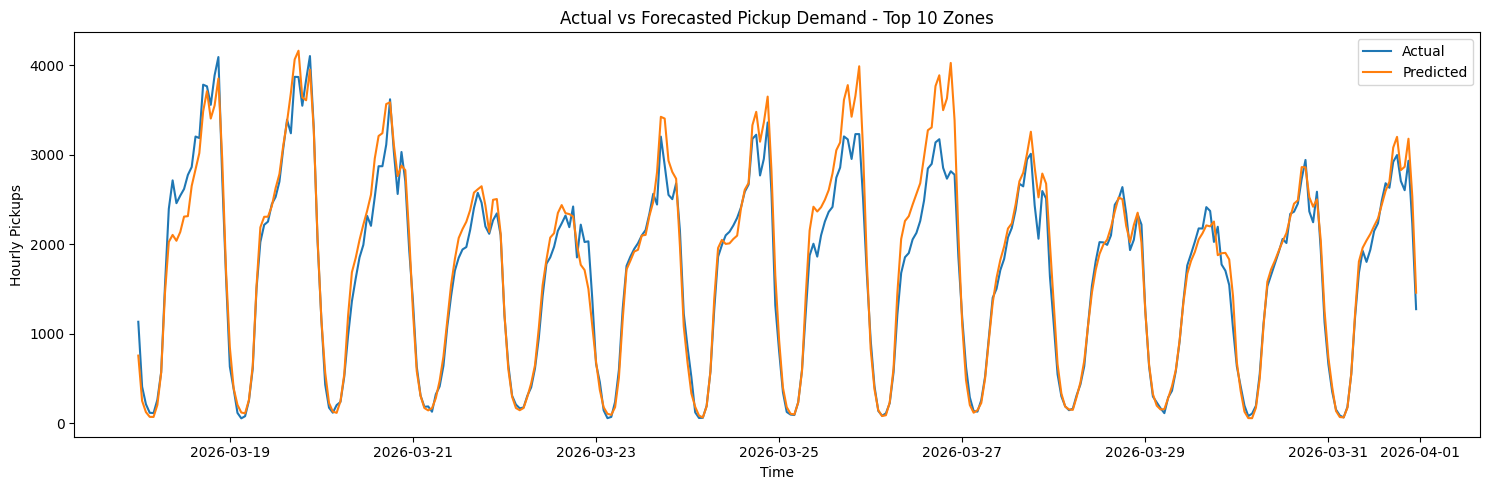

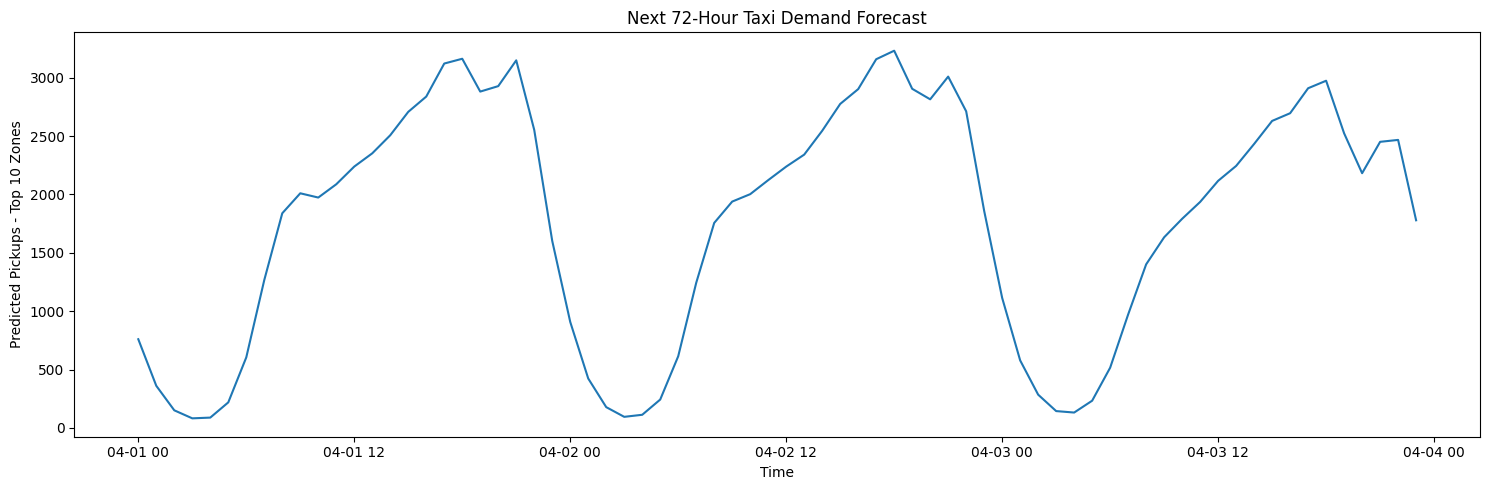

In [24]:
# =========================================================
# PLOT 1 — ACTUAL VS PREDICTED
# =========================================================

actual_vs_pred = (
    final_test_predictions
    .groupby(TIME_COL)[
        [
            TARGET,
            "predicted_demand"
        ]
    ]
    .sum()
    .reset_index()
)

plt.figure(figsize=(15, 5))

plt.plot(
    actual_vs_pred[TIME_COL],
    actual_vs_pred[TARGET],
    label="Actual"
)

plt.plot(
    actual_vs_pred[TIME_COL],
    actual_vs_pred["predicted_demand"],
    label="Predicted"
)

plt.title(
    "Actual vs Forecasted Pickup Demand - Top 10 Zones"
)

plt.xlabel("Time")
plt.ylabel("Hourly Pickups")

plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "forecast_vs_actual.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# PLOT 2 — FUTURE 72-HOUR FORECAST
# =========================================================

future_total = (
    future_forecast
    .groupby(TIME_COL)[
        "predicted_demand"
    ]
    .sum()
    .reset_index()
)

plt.figure(figsize=(15, 5))

plt.plot(
    future_total[TIME_COL],
    future_total[
        "predicted_demand"
    ]
)

plt.title(
    "Next 72-Hour Taxi Demand Forecast"
)

plt.xlabel("Time")
plt.ylabel(
    "Predicted Pickups - Top 10 Zones"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "future_72h_forecast.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()